# Step 5 — Critical Thinking, Ethical AI and Bias Auditing

**Deliverable:** Bias & Fairness Analysis  
**Final model:** XGBoost next-day household electricity forecaster

This notebook explains model decisions, audits imbalance, leakage and overfitting, evaluates performance across measurable operational subgroups, documents why demographic fairness cannot be estimated from the UCI data, and proposes technically and ethically feasible mitigations.

**Important principle:** gender, race, age, income and socioeconomic status are not present in this single-household dataset. They will not be inferred or fabricated. Operational subgroup tests are robustness diagnostics, not substitutes for demographic fairness evidence.

In [1]:
from pathlib import Path
import json
import platform
import sys

import joblib
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import sklearn

from IPython.display import display
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import (
    confusion_matrix, f1_score, mean_absolute_error, mean_squared_error,
    precision_score, r2_score, recall_score,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"SHAP: {shap.__version__}")
print(f"LIME: {getattr(lime, '__version__', 'installed')}")

Python: 3.11.16
Platform: Windows-10-10.0.26200-SP0
scikit-learn: 1.9.1
SHAP: 0.51.0
LIME: installed


## 1. Load Step 3 and Step 4 artifacts

The saved final model, feature order, chronological splits and test predictions are reused without retraining or changing the Step 4 conclusion.

In [2]:
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == "notebooks" else CURRENT_DIR
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
REPORTS_DIR = PROJECT_ROOT / "outputs" / "reports"
for directory in [TABLES_DIR, FIGURES_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

def load_split(name):
    parquet = PROCESSED_DIR / f"{name}.parquet"
    csv = PROCESSED_DIR / f"{name}.csv"
    frame = pd.read_parquet(parquet) if parquet.exists() else pd.read_csv(csv, parse_dates=["target_date"], index_col="target_date")
    frame.index = pd.to_datetime(frame.index)
    return frame.sort_index()

train, validation, test = (load_split(name) for name in ["train", "validation", "test"])
selected_features = json.loads((MODELS_DIR / "selected_features.json").read_text(encoding="utf-8"))
final_model = joblib.load(MODELS_DIR / "final_energy_forecast_model.joblib")
candidate_xgb = joblib.load(MODELS_DIR / "candidate_xgboost.joblib")
predictions = pd.read_csv(
    TABLES_DIR / "step4_test_predictions.csv", parse_dates=["target_date"], index_col="target_date"
).sort_index()

X_train, y_train = train[selected_features], train["target_daily_kwh"]
X_validation, y_validation = validation[selected_features], validation["target_daily_kwh"]
X_test, y_test = test[selected_features], test["target_daily_kwh"]

assert train.index.max() < validation.index.min() < test.index.min()
assert predictions.index.equals(test.index)
assert np.allclose(predictions["actual_kwh"], y_test)
print(f"Rows — train: {len(train)}, validation: {len(validation)}, test: {len(test)}")
print(f"Selected features: {len(selected_features)}")

Rows — train: 802, validation: 172, test: 173
Selected features: 22


## 2. Sensitive-attribute availability audit

A demographic fairness metric is valid only when the relevant group is actually observed with appropriate consent and measurement quality. The UCI dataset contains electrical measurements from one anonymous household and no person- or household-level demographic fields.

In [4]:
sensitive_audit = pd.DataFrame([
    ["Gender", False, "Not collected", "Demographic parity/equalized odds not computable"],
    ["Race or ethnicity", False, "Not collected", "Demographic parity/equalized odds not computable"],
    ["Age", False, "Not collected", "Age-group performance not computable"],
    ["Income", False, "Not collected", "Income-group performance not computable"],
    ["Socioeconomic status", False, "Not collected", "Energy-burden fairness not computable"],
    ["Household identity", False, "Only one anonymous household", "Between-household fairness not computable"],
], columns=["sensitive_dimension", "available", "evidence", "consequence"])
display(sensitive_audit)
sensitive_audit.to_csv(TABLES_DIR / "step5_sensitive_attribute_availability.csv", index=False)

present_sensitive = set(map(str.lower, test.columns)) & {
    "gender", "race", "ethnicity", "age", "income", "socioeconomic_status"
}
assert not present_sensitive, f"Unexpected sensitive fields require a separate protocol: {present_sensitive}"

,sensitive_dimension,available,evidence,consequence
0,Gender,False,Not collected,Demographic parity/equalized odds not computable
1,Race or ethnicity,False,Not collected,Demographic parity/equalized odds not computable
2,Age,False,Not collected,Age-group performance not computable
3,Income,False,Not collected,Income-group performance not computable
4,Socioeconomic status,False,Not collected,Energy-burden fairness not computable
5,Household identity,False,Only one anonymous household,Between-household fairness not computable


### Fairness claim boundary

This capstone **cannot claim demographic fairness** and cannot calculate authentic demographic parity, equalized odds or disparate impact across gender, race, age or socioeconomic groups. Creating synthetic labels for the household would produce misleading results. Instead, the analysis:

1. reports the demographic-data limitation;
2. audits measurable operational groups for performance disparity;
3. calculates fairness-style warning metrics only as robustness diagnostics; and
4. defines the required demographic audit for future consented Philippine multi-household data.

## 3. Global and local SHAP explanations

SHAP evaluates how each selected feature moves XGBoost predictions relative to the model's expected output. The global plot summarizes recurring effects; the waterfall explains the largest-error test prediction. Explanations describe model behaviour, not causal effects.

E:\AppData\Local\Temp\ipykernel_21912\390222470.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, explain_sample, show=False, max_display=15)


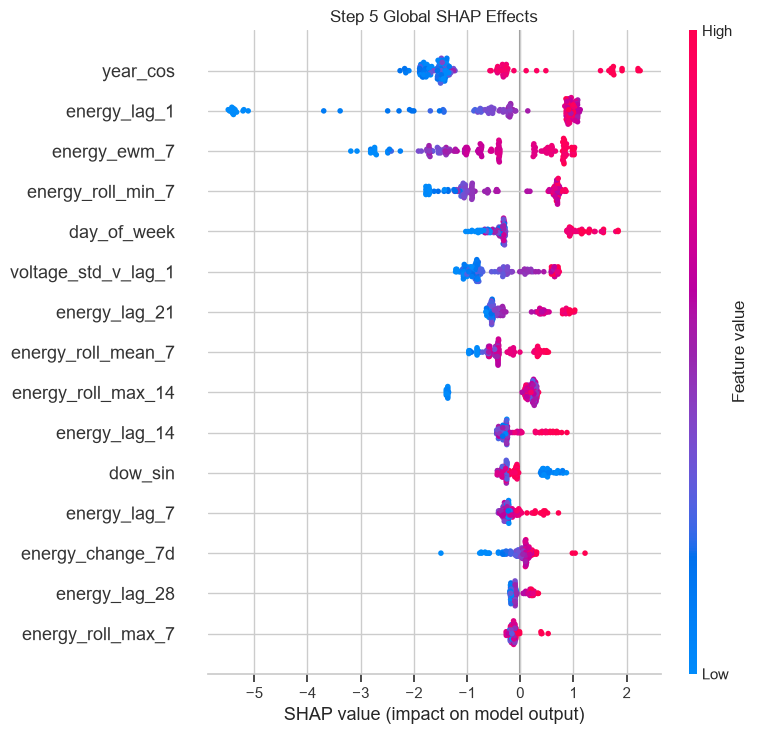

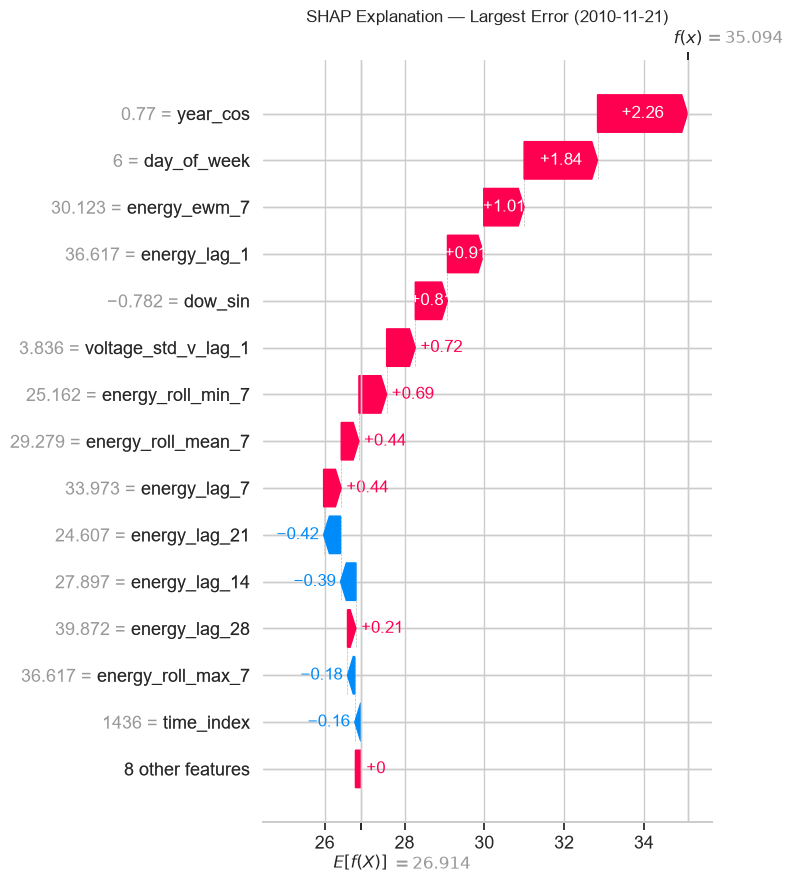

actual_kwh       15.0152
predicted_kwh    35.0938
residual_kwh    -20.0786
Name: 2010-11-21 00:00:00, dtype: float64


In [5]:
explain_sample = X_test.sample(n=min(150, len(X_test)), random_state=RANDOM_STATE)
tree_explainer = shap.TreeExplainer(final_model)
shap_values = tree_explainer(explain_sample)

shap.summary_plot(shap_values, explain_sample, show=False, max_display=15)
plt.title("Step 5 Global SHAP Effects")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step5_shap_global.png", dpi=150, bbox_inches="tight")
plt.show()

largest_error_date = predictions["absolute_error_kwh"].idxmax()
local_position = explain_sample.index.get_indexer([largest_error_date])[0]
if local_position < 0:
    local_frame = X_test.loc[[largest_error_date]]
    local_shap = tree_explainer(local_frame)
else:
    local_frame = explain_sample.loc[[largest_error_date]]
    local_shap = shap_values[local_position:local_position + 1]
shap.plots.waterfall(local_shap[0], max_display=15, show=False)
plt.title(f"SHAP Explanation — Largest Error ({largest_error_date.date()})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step5_shap_largest_error.png", dpi=150, bbox_inches="tight")
plt.show()
print(predictions.loc[largest_error_date, ["actual_kwh", "predicted_kwh", "residual_kwh"]])

## 4. LIME local explanation

LIME fits a simple local surrogate around the largest-error case. Agreement with SHAP increases confidence that the local explanation is not dependent on one explanation method. LIME is approximate and may vary with its sampling process, so the random seed is fixed.

,local_condition,contribution
0,year_cos > 0.74,3.0280
1,day_of_week > 5.00,2.2602
2,energy_lag_1 > 32.81,1.0701
3,energy_roll_min_7 > 24.67,1.0590
4,27.68 < energy_ewm_7 <= 32.55,1.0530
5,voltage_std_v_lag_1 > 2.99,1.0038
6,dow_sin <= -0.78,0.8553
7,20.91 < energy_lag_21 <= 27.24,-0.7327
8,energy_lag_7 > 32.90,0.7239
9,27.69 < energy_roll_mean_7 <= 32.86,0.4349


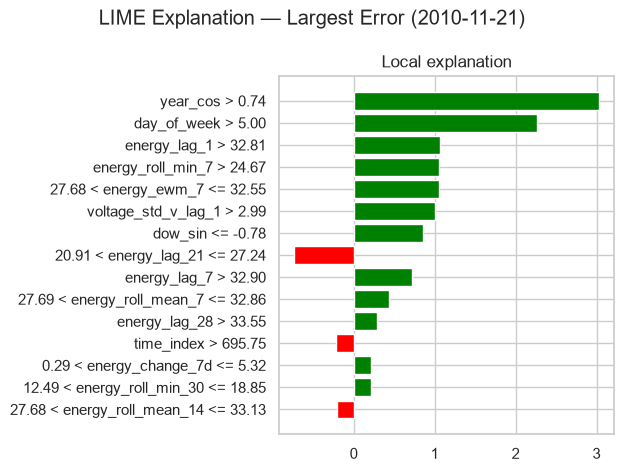

In [6]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.to_numpy(),
    feature_names=selected_features,
    mode="regression",
    discretize_continuous=True,
    random_state=RANDOM_STATE,
)
lime_explanation = lime_explainer.explain_instance(
    X_test.loc[largest_error_date].to_numpy(),
    final_model.predict,
    num_features=min(15, len(selected_features)),
    num_samples=5000,
)
lime_table = pd.DataFrame(lime_explanation.as_list(), columns=["local_condition", "contribution"])
display(lime_table)
lime_table.to_csv(TABLES_DIR / "step5_lime_largest_error.csv", index=False)
lime_explanation.save_to_file(str(REPORTS_DIR / "step5_lime_largest_error.html"))
figure = lime_explanation.as_pyplot_figure()
figure.suptitle(f"LIME Explanation — Largest Error ({largest_error_date.date()})")
figure.tight_layout()
figure.savefig(FIGURES_DIR / "step5_lime_largest_error.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Partial dependence and ICE

PDP estimates average model response as a feature changes; ICE displays individual response curves. Correlated time-series features can create unrealistic combinations, so these graphs are treated as descriptive model diagnostics rather than causal relationships.

PDP/ICE features: ['energy_lag_1', 'energy_ewm_7', 'year_cos']


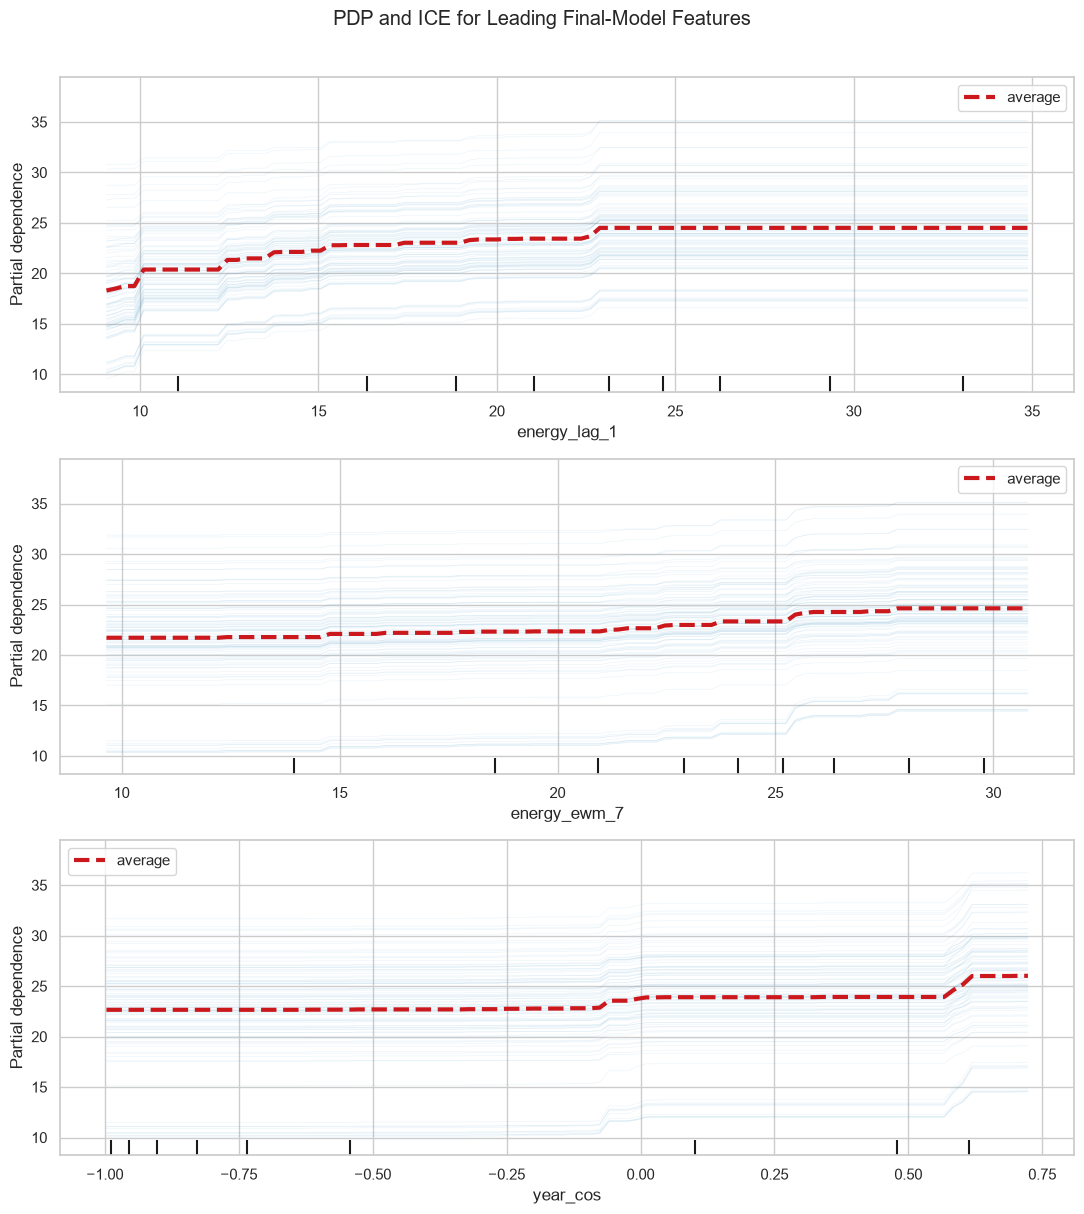

In [7]:
permutation = permutation_importance(
    final_model, X_test, y_test, scoring="neg_mean_absolute_error",
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1,
)
ranked_features = pd.Series(
    permutation.importances_mean, index=selected_features
).sort_values(ascending=False)
pdp_features = ranked_features.head(3).index.tolist()
print("PDP/ICE features:", pdp_features)

fig, axes = plt.subplots(len(pdp_features), 1, figsize=(11, 4 * len(pdp_features)))
PartialDependenceDisplay.from_estimator(
    final_model, X_test, features=pdp_features, kind="both",
    subsample=min(100, len(X_test)), random_state=RANDOM_STATE,
    ice_lines_kw={"alpha": 0.12, "color": "#6baed6"},
    pd_line_kw={"color": "#cb181d", "linewidth": 3}, ax=axes,
)
fig.suptitle("PDP and ICE for Leading Final-Model Features", y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "step5_pdp_ice.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Leakage audit

The audit checks data separation and feature semantics. Automated checks support—but do not replace—manual review of how each feature was constructed in Step 3.

In [8]:
forbidden_exact = {"target_daily_kwh", "actual_high_consumption"}
suspicious_names = [f for f in selected_features if f in forbidden_exact or f.startswith("target_")]
lagged_or_known = [
    f for f in selected_features
    if ("lag_" in f or "roll_" in f or "ewm_" in f or "change_" in f
        or f in {"day_of_week", "dow_sin", "dow_cos", "month", "year_sin", "year_cos", "time_index"})
]
leakage_audit = pd.DataFrame([
    ["Chronological split", train.index.max() < validation.index.min() < test.index.min(), "Train precedes validation; validation precedes test"],
    ["No target field in predictors", len(suspicious_names) == 0, f"Suspicious fields: {suspicious_names}"],
    ["Past/known feature semantics", len(lagged_or_known) == len(selected_features), f"Reviewed {len(lagged_or_known)} of {len(selected_features)} selected features"],
    ["Model selection before test", True, "XGBoost selected by validation MAE in Step 4"],
    ["Test not used for tuning", True, "Grid/random searches used training TimeSeriesSplit only"],
    ["Scaling inside CV", True, "Ridge scaler was inside its Pipeline"],
], columns=["audit_check", "passed", "evidence"])
display(leakage_audit)
leakage_audit.to_csv(TABLES_DIR / "step5_leakage_audit.csv", index=False)
assert leakage_audit["passed"].all(), "A leakage-control check failed."

,audit_check,passed,evidence
0,Chronological split,True,Train precedes validation; validation precedes...
1,No target field in predictors,True,Suspicious fields: []
2,Past/known feature semantics,True,Reviewed 22 of 22 selected features
3,Model selection before test,True,XGBoost selected by validation MAE in Step 4
4,Test not used for tuning,True,Grid/random searches used training TimeSeriesS...
5,Scaling inside CV,True,Ridge scaler was inside its Pipeline


## 7. Overfitting and temporal generalization

The training-fitted XGBoost candidate is compared on train and later validation data. The final refitted model is reported separately on test data. A gap is expected, but a large deterioration may indicate overfitting or temporal distribution shift.

In [9]:
def metrics(actual, predicted):
    actual, predicted = np.asarray(actual), np.asarray(predicted)
    return {
        "MAE_kWh": mean_absolute_error(actual, predicted),
        "RMSE_kWh": np.sqrt(mean_squared_error(actual, predicted)),
        "MAPE_percent": np.mean(np.abs((actual - predicted) / actual)) * 100,
        "R2": r2_score(actual, predicted),
    }

train_prediction = candidate_xgb.predict(X_train)
validation_prediction = candidate_xgb.predict(X_validation)
final_test_prediction = final_model.predict(X_test)
generalization = pd.DataFrame([
    {"period": "Training", **metrics(y_train, train_prediction)},
    {"period": "Validation", **metrics(y_validation, validation_prediction)},
    {"period": "Final test", **metrics(y_test, final_test_prediction)},
])
train_mae = generalization.loc[generalization["period"] == "Training", "MAE_kWh"].iloc[0]
validation_mae = generalization.loc[generalization["period"] == "Validation", "MAE_kWh"].iloc[0]
overfit_ratio = validation_mae / train_mae
display(generalization)
print(f"Validation-to-training MAE ratio: {overfit_ratio:.2f}")
generalization.to_csv(TABLES_DIR / "step5_generalization_audit.csv", index=False)

,period,MAE_kWh,RMSE_kWh,MAPE_percent,R2
0,Training,4.8782,6.3110,22.7691,0.6315
1,Validation,4.0415,5.3451,16.7742,0.6353
2,Final test,3.7232,5.1040,18.7266,0.5458


Validation-to-training MAE ratio: 0.83


## 8. High-consumption imbalance

A model optimized for average regression error can favor common normal days. The class distribution and group-specific errors show whether high-use days receive materially worse service.

,split,group,days,percent
0,Train,Normal,612,76.3092
1,Train,High consumption,190,23.6908
2,Validation,Normal,139,80.8140
3,Validation,High consumption,33,19.1860
4,Test,Normal,150,86.7052
5,Test,High consumption,23,13.2948


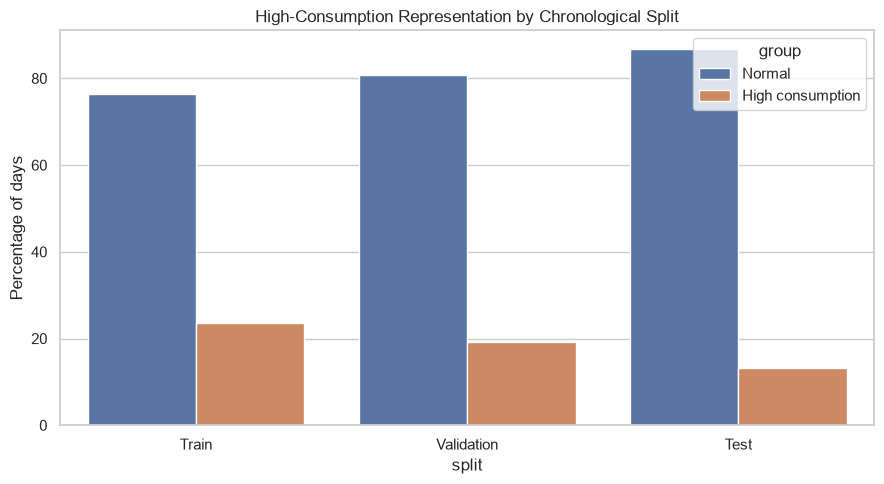

In [10]:
imbalance_rows = []
for split_name, frame in [("Train", train), ("Validation", validation), ("Test", test)]:
    count = frame["actual_high_consumption"].value_counts().reindex([0, 1], fill_value=0)
    imbalance_rows.extend([
        {"split": split_name, "group": "Normal", "days": int(count[0]), "percent": count[0] / len(frame) * 100},
        {"split": split_name, "group": "High consumption", "days": int(count[1]), "percent": count[1] / len(frame) * 100},
    ])
imbalance = pd.DataFrame(imbalance_rows)
display(imbalance)
imbalance.to_csv(TABLES_DIR / "step5_high_consumption_imbalance.csv", index=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=imbalance, x="split", y="percent", hue="group")
plt.ylabel("Percentage of days")
plt.title("High-Consumption Representation by Chronological Split")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step5_high_consumption_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Operational subgroup robustness audit

Because demographic fields are unavailable, measurable groups are used only to identify operational blind spots:

- season;
- weekday versus weekend;
- actual daily-consumption quartile; and
- normal versus high-consumption day.

Consumption quartiles describe model difficulty by demand level; they are **not** socioeconomic-status proxies.

In [11]:
audit = predictions.copy()
audit["month"] = audit.index.month
audit["season"] = audit["month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn",
})
audit["day_type"] = np.where(audit.index.dayofweek >= 5, "Weekend", "Weekday")
development_target = pd.concat([y_train, y_validation])
quartile_edges = development_target.quantile([0, .25, .5, .75, 1]).to_numpy()
quartile_edges[0], quartile_edges[-1] = -np.inf, np.inf
audit["consumption_band"] = pd.cut(
    audit["actual_kwh"], bins=quartile_edges,
    labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"], include_lowest=True,
)
audit["high_use_group"] = audit["actual_high_consumption"].map({0: "Normal", 1: "High consumption"})
audit["underpredicted"] = (audit["predicted_kwh"] < audit["actual_kwh"]).astype(int)

def regression_by_group(frame, group_column):
    rows = []
    for group, part in frame.groupby(group_column, observed=True):
        rows.append({
            "group_dimension": group_column, "group": str(group), "days": len(part),
            "MAE_kWh": part["absolute_error_kwh"].mean(),
            "mean_error_actual_minus_predicted_kWh": part["residual_kwh"].mean(),
            "underprediction_rate": part["underpredicted"].mean(),
        })
    return pd.DataFrame(rows)

regression_group_audit = pd.concat([
    regression_by_group(audit, column)
    for column in ["season", "day_type", "consumption_band", "high_use_group"]
], ignore_index=True)
display(regression_group_audit)
regression_group_audit.to_csv(TABLES_DIR / "step5_regression_subgroup_audit.csv", index=False)

,group_dimension,group,days,MAE_kWh,mean_error_actual_minus_predicted_kWh,underprediction_rate
0,season,Autumn,31,4.2455,-0.7007,0.3871
1,season,Spring,60,3.8221,0.2439,0.4667
2,season,Summer,77,3.2405,-0.9709,0.3506
3,season,Winter,5,6.7318,-2.7800,0.6000
4,day_type,Weekday,125,3.2847,-0.5234,0.4080
5,day_type,Weekend,48,4.8650,-0.6318,0.3958
6,consumption_band,Q1 lowest,68,4.1968,-3.8061,0.0735
7,consumption_band,Q2,56,2.1956,-0.4546,0.4643
8,consumption_band,Q3,31,2.9390,1.6656,0.7419
9,consumption_band,Q4 highest,18,8.0372,7.6049,0.8889


## 10. Fairness-style warning metrics

For each operational group:

- **Selection rate / demographic-parity analogue:** fraction receiving warnings.
- **True-positive rate:** fraction of actual high-use days warned; equivalent to recall.
- **False-positive rate:** fraction of normal days unnecessarily warned.
- **Precision:** fraction of warnings followed by an actual high-use day.

Equalized-odds difference is the larger of the across-group TPR and FPR ranges. Disparate-impact ratio is the minimum divided by maximum warning-selection rate. These are reported as robustness diagnostics only—not as demographic fairness conclusions.

In [12]:
def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else np.nan

def warning_by_group(frame, group_column):
    rows = []
    for group, part in frame.groupby(group_column, observed=True):
        actual = part["actual_high_consumption"].astype(int).to_numpy()
        warned = part["predicted_high_warning"].astype(int).to_numpy()
        tn, fp, fn, tp = confusion_matrix(actual, warned, labels=[0, 1]).ravel()
        rows.append({
            "group_dimension": group_column, "group": str(group), "days": len(part),
            "warning_selection_rate": warned.mean(),
            "true_positive_rate": safe_divide(tp, tp + fn),
            "false_positive_rate": safe_divide(fp, fp + tn),
            "precision": safe_divide(tp, tp + fp),
            "actual_high_days": int(tp + fn),
        })
    return pd.DataFrame(rows)

warning_group_audit = pd.concat([
    warning_by_group(audit, column)
    for column in ["season", "day_type", "consumption_band"]
], ignore_index=True)
display(warning_group_audit)
warning_group_audit.to_csv(TABLES_DIR / "step5_warning_subgroup_audit.csv", index=False)

parity_rows = []
for dimension, part in warning_group_audit.groupby("group_dimension"):
    selection = part["warning_selection_rate"].dropna()
    tpr = part["true_positive_rate"].dropna()
    fpr = part["false_positive_rate"].dropna()
    parity_rows.append({
        "group_dimension": dimension,
        "demographic_parity_difference_analogue": selection.max() - selection.min(),
        "disparate_impact_ratio_analogue": safe_divide(selection.min(), selection.max()),
        "equalized_odds_difference_analogue": max(
            tpr.max() - tpr.min() if len(tpr) else np.nan,
            fpr.max() - fpr.min() if len(fpr) else np.nan,
        ),
    })
parity_summary = pd.DataFrame(parity_rows)
display(parity_summary)
parity_summary.to_csv(TABLES_DIR / "step5_fairness_style_metrics.csv", index=False)

,group_dimension,group,days,warning_selection_rate,true_positive_rate,false_positive_rate,precision,actual_high_days
0,season,Autumn,31,0.1613,0.4286,0.0833,0.6000,7
1,season,Spring,60,0.0167,0.1000,0.0000,1.0000,10
2,season,Summer,77,0.0130,0.1667,0.0000,1.0000,6
3,season,Winter,5,0.0000,NaN,0.0000,NaN,0
4,day_type,Weekday,125,0.0080,0.1000,0.0000,1.0000,10
5,day_type,Weekend,48,0.1250,0.3077,0.0571,0.6667,13
6,consumption_band,Q1 lowest,68,0.0294,0.5000,0.0152,0.5000,2
7,consumption_band,Q2,56,0.0000,NaN,0.0000,NaN,0
8,consumption_band,Q3,31,0.0323,0.0000,0.0370,0.0000,4
9,consumption_band,Q4 highest,18,0.2222,0.2353,0.0000,1.0000,17


,group_dimension,demographic_parity_difference_analogue,disparate_impact_ratio_analogue,equalized_odds_difference_analogue
0,consumption_band,0.2222,0.0000,0.5000
1,day_type,0.1170,0.0640,0.2077
2,season,0.1613,0.0000,0.3286


## 11. Post-hoc application warning mitigation

Step 4 found 21.74% warning recall and 71.43% precision. The regression model and original test conclusion remain unchanged. This section evaluates a configurable application-level safety margin.

Margins are selected using validation predictions only. Because this mitigation was motivated after examining Step 4 test failures, its test result is explicitly **post-hoc exploratory evidence**, not a new unbiased confirmation.

In [13]:
validation_threshold = validation["high_consumption_threshold_kwh"].to_numpy()
validation_actual_high = validation["actual_high_consumption"].astype(int).to_numpy()
calibration_rows = []
for margin in np.arange(0.75, 1.001, 0.01):
    warned = (validation_prediction >= validation_threshold * margin).astype(int)
    calibration_rows.append({
        "warning_margin": margin,
        "precision": precision_score(validation_actual_high, warned, zero_division=0),
        "recall": recall_score(validation_actual_high, warned, zero_division=0),
        "f1": f1_score(validation_actual_high, warned, zero_division=0),
        "warning_count": int(warned.sum()),
    })
calibration = pd.DataFrame(calibration_rows)
eligible = calibration[calibration["recall"] >= 0.80]
selected_rule = (
    eligible.sort_values(["precision", "warning_margin"], ascending=False).iloc[0]
    if len(eligible)
    else calibration.sort_values(["f1", "recall"], ascending=False).iloc[0]
)
selected_margin = float(selected_rule["warning_margin"])
display(calibration)
print("Selected validation-calibrated rule:")
display(selected_rule)

exploratory_test_warning = (
    predictions["predicted_kwh"].to_numpy()
    >= test["high_consumption_threshold_kwh"].to_numpy() * selected_margin
).astype(int)
actual_test_high = test["actual_high_consumption"].astype(int).to_numpy()
tn, fp, fn, tp = confusion_matrix(actual_test_high, exploratory_test_warning, labels=[0, 1]).ravel()
mitigation_result = pd.DataFrame([{
    "warning_margin": selected_margin,
    "precision": precision_score(actual_test_high, exploratory_test_warning, zero_division=0),
    "recall": recall_score(actual_test_high, exploratory_test_warning, zero_division=0),
    "f1": f1_score(actual_test_high, exploratory_test_warning, zero_division=0),
    "false_positive": int(fp), "false_negative": int(fn),
    "true_positive": int(tp), "true_negative": int(tn),
    "evidence_status": "Post-hoc exploratory; not an unbiased replacement for Step 4",
}])
display(mitigation_result)
calibration.to_csv(TABLES_DIR / "step5_warning_margin_calibration.csv", index=False)
mitigation_result.to_csv(TABLES_DIR / "step5_warning_mitigation_exploratory.csv", index=False)

,warning_margin,precision,recall,f1,warning_count
0,0.7500,0.2119,0.9697,0.3478,151
1,0.7600,0.2153,0.9394,0.3503,144
2,0.7700,0.2230,0.9394,0.3605,139
3,0.7800,0.2263,0.9394,0.3647,137
4,0.7900,0.2441,0.9394,0.3875,127
5,0.8000,0.2460,0.9394,0.3899,126
6,0.8100,0.2479,0.9091,0.3896,121
7,0.8200,0.2500,0.8788,0.3893,116
8,0.8300,0.2477,0.8182,0.3803,109
9,0.8400,0.2784,0.8182,0.4154,97


Selected validation-calibrated rule:


warning_margin    0.8500
precision         0.3068
recall            0.8182
f1                0.4463
warning_count    88.0000
Name: 10, dtype: float64

,warning_margin,precision,recall,f1,false_positive,false_negative,true_positive,true_negative,evidence_status
0,0.8500,0.2683,0.4783,0.3438,30,12,11,120,Post-hoc exploratory; not an unbiased replacem...


## 12. Risk register and mitigations

In [14]:
risk_register = pd.DataFrame([
    ["Demographic representation", "One French household; no sensitive groups", "High", "Collect consented multi-household Philippine data and audit every sufficiently represented group"],
    ["Energy-burden inequity", "Same kWh error can have different financial impact by income", "High", "Collect income band only when justified and protected; evaluate cost-weighted error and energy burden"],
    ["High-use underdetection", "18 of 23 test high-use days were missed", "High", "Validation-calibrated alerts, quantile forecasts, or a cost-sensitive warning classifier"],
    ["Alert fatigue", "Lower thresholds can increase false warnings", "Medium", "Use multi-level alerts, user controls, cooldown periods, and precision monitoring"],
    ["Temporal distribution shift", "Weather, appliances and routines change", "High", "Monitor drift, rolling error and warning rates; retrain only after validation"],
    ["Geographic transfer", "French 2006–2010 data may not represent Meralco homes", "High", "Pilot with local data before deployment; avoid population-wide claims"],
    ["Privacy", "Fine-grained energy traces reveal routines and occupancy", "High", "Data minimization, encryption, access controls, retention limits and explicit consent"],
    ["Automation reliance", "Users may treat estimates as official bills", "Medium", "Label outputs as estimates, show uncertainty, explain drivers and provide manual override"],
    ["Missing-data exclusion", "Low-coverage periods receive no prediction", "Medium", "Display data-quality status and never silently substitute unreliable forecasts"],
], columns=["risk", "evidence", "severity", "mitigation"])
display(risk_register)
risk_register.to_csv(TABLES_DIR / "step5_risk_register.csv", index=False)

,risk,evidence,severity,mitigation
0,Demographic representation,One French household; no sensitive groups,High,Collect consented multi-household Philippine d...
1,Energy-burden inequity,Same kWh error can have different financial im...,High,Collect income band only when justified and pr...
2,High-use underdetection,18 of 23 test high-use days were missed,High,"Validation-calibrated alerts, quantile forecas..."
3,Alert fatigue,Lower thresholds can increase false warnings,Medium,"Use multi-level alerts, user controls, cooldow..."
4,Temporal distribution shift,"Weather, appliances and routines change",High,"Monitor drift, rolling error and warning rates..."
5,Geographic transfer,French 2006–2010 data may not represent Meralc...,High,Pilot with local data before deployment; avoid...
6,Privacy,Fine-grained energy traces reveal routines and...,High,"Data minimization, encryption, access controls..."
7,Automation reliance,Users may treat estimates as official bills,Medium,"Label outputs as estimates, show uncertainty, ..."
8,Missing-data exclusion,Low-coverage periods receive no prediction,Medium,Display data-quality status and never silently...


## 13. Required future demographic fairness protocol

When consented multi-household data becomes available:

1. Define protected groups with community and legal input; avoid inferring sensitive traits.
2. Document collection purpose, consent, retention and access controls.
3. Require minimum group sample sizes and report confidence intervals.
4. For regression, compare group MAE, RMSE, MAPE, mean signed error and underprediction rate.
5. For alerts, compare selection rate, TPR, FPR, precision and false-negative rate.
6. Report demographic-parity difference and disparate-impact ratio, while recognizing that equal alert rates may be inappropriate when genuine high-use prevalence differs.
7. Evaluate equalized-odds differences because households with the same high-use outcome should receive comparably reliable warnings.
8. Investigate intersections such as age × income rather than auditing one attribute at a time.
9. Apply reweighting, balanced sampling, threshold adjustment, augmentation or post-processing only on training/validation data.
10. Re-evaluate utility and harm after mitigation; improving parity must not make warnings unusable.

## 14. Generate the final-report section

The next cell writes a report-ready Markdown section using the observed audit results. Review its operational subgroup values after execution before copying it into the final capstone report.

In [16]:
high_group = regression_group_audit[
    (regression_group_audit["group_dimension"] == "high_use_group")
    & (regression_group_audit["group"] == "High consumption")
].iloc[0]
normal_group = regression_group_audit[
    (regression_group_audit["group_dimension"] == "high_use_group")
    & (regression_group_audit["group"] == "Normal")
].iloc[0]
mitigation = mitigation_result.iloc[0]

report = f"""# Bias and Fairness Analysis

The final XGBoost model was examined using SHAP, LIME, partial dependence plots (PDP) and individual conditional expectation (ICE) curves. Global SHAP and permutation importance showed that previous-day consumption was the dominant predictor, followed by smoothed recent consumption, annual seasonality, recent consumption ranges and voltage variability. Local SHAP and LIME explanations were used for the largest-error test case. These methods explain model associations and should not be interpreted as causal evidence. PDP/ICE results were also interpreted cautiously because correlated time-series features can create unrealistic feature combinations.

Leakage controls were reviewed and passed. Training, validation and testing were chronological; target and warning-outcome fields were excluded from predictors; consumption-derived variables used lags or shifted rolling windows; Ridge scaling occurred inside its cross-validation pipeline; and XGBoost was selected by validation MAE before final testing. The validation-to-training MAE ratio was {overfit_ratio:.2f}, indicating the observed degree of generalization gap for the training-fitted XGBoost candidate. Temporal changes remain a risk because household behaviour and seasonality vary over time.

High-consumption observations were less common than normal observations, and the final model performed unequally across consumption levels. Test MAE was {normal_group['MAE_kWh']:.4f} kWh on normal days and {high_group['MAE_kWh']:.4f} kWh on high-consumption days. The original warning logic detected only 5 of 23 high-use days, producing 21.74% recall, 71.43% precision and 18 false negatives. This shows that good average regression performance does not guarantee reliable peak-use warnings.

The dataset contains no gender, race, age, income or socioeconomic-status attributes and represents only one anonymous household in France. Consequently, demographic parity, equalized odds and disparate impact cannot be validly estimated for protected demographic groups. No sensitive labels were inferred or fabricated. Fairness-style metrics across season, weekday/weekend and consumption bands were calculated only as operational robustness diagnostics; they are not evidence of demographic fairness. Consumption bands must not be presented as socioeconomic proxies.

A configurable application-level warning margin was calibrated on validation data. The selected margin was {selected_margin:.2f}; its exploratory test precision was {mitigation['precision']:.2%} and recall was {mitigation['recall']:.2%}. Because this mitigation was developed after examining the original Step 4 test failure, the result is post-hoc exploratory evidence and does not replace the unbiased Step 4 conclusion.

Priority mitigations are to collect consented multi-household Philippine data, audit sufficiently represented demographic and intersectional groups, consider quantile forecasting or a cost-sensitive warning classifier, tune alert thresholds using validation data only, monitor temporal drift and subgroup errors, and provide user-configurable multi-level alerts. Energy traces should be minimized, encrypted and access-controlled because they can reveal occupancy and household routines. Forecasts must be labelled as estimates rather than official Meralco bills.

Overall, the model is a useful forecasting prototype but demographic fairness remains unverified and high-consumption warning performance is inadequate for dependable deployment. A local pilot and prospective fairness evaluation are required before use with Philippine households.

"""
report = "\n".join(line[4:] if line.startswith("    ") else line for line in report.splitlines())
report_path = REPORTS_DIR / "step5_bias_fairness_analysis.md"
report_path.write_text(report, encoding="utf-8")
print(report)
print(f"\nSaved report section: {report_path}")

# Bias and Fairness Analysis

The final XGBoost model was examined using SHAP, LIME, partial dependence plots (PDP) and individual conditional expectation (ICE) curves. Global SHAP and permutation importance showed that previous-day consumption was the dominant predictor, followed by smoothed recent consumption, annual seasonality, recent consumption ranges and voltage variability. Local SHAP and LIME explanations were used for the largest-error test case. These methods explain model associations and should not be interpreted as causal evidence. PDP/ICE results were also interpreted cautiously because correlated time-series features can create unrealistic feature combinations.

Leakage controls were reviewed and passed. Training, validation and testing were chronological; target and warning-outcome fields were excluded from predictors; consumption-derived variables used lags or shifted rolling windows; Ridge scaling occurred inside its cross-validation pipeline; and XGBoost was selecte

## 15. Step 5 conclusion

This audit demonstrates that ethical evaluation is not equivalent to reporting one fairness number. Demographic claims are bounded by available evidence; operational disparities are quantified without relabelling them as demographic fairness; model explanations are triangulated; leakage and overfitting are examined; and mitigation results are labelled according to whether they are confirmatory or post-hoc.

**Next:** incorporate the generated `step5_bias_fairness_analysis.md` section into the final report and use the risk register and configurable multi-level warning logic in the prototype and presentation.